## Лабораторная работа "Определение трезвучия"

Выполнила Пелсе Александра, магистратура 1 курс, Речевые технологии и МО.
январь, 2026 год

Задача:
дан wav файл с сигналом трезвучия. 
Необходимо определить тональность трезвучия.

Частота дискретизации: 16000
Количество отсчётов: 80000
F1: 138.671875
F2: 416.015625
F3: 656.25

Основные тона: E, B, G

Подходящие тональности: Ми минор


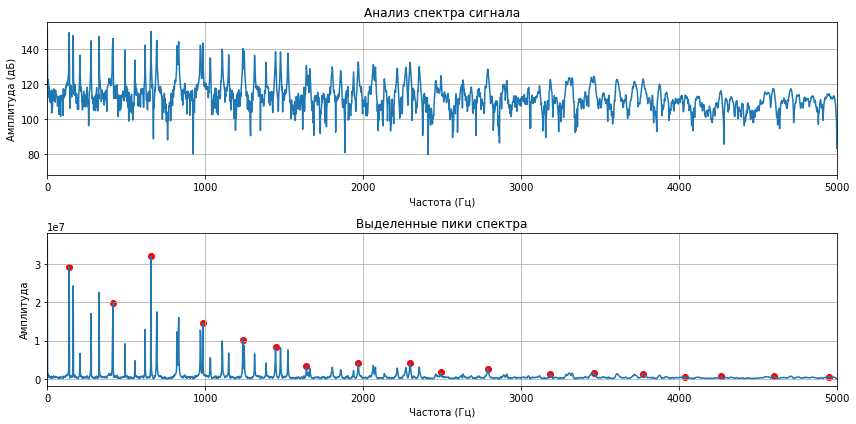

In [8]:
import numpy as np
from scipy.io import wavfile
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Чтение WAV файла
samplerate, data = wavfile.read('DTLab8.wav')
print(f'Частота дискретизации: {samplerate}')
print(f'Количество отсчётов: {len(data)}')

# Параметры быстрого преобразования Фурье
NFFT = 8192
Fs = samplerate
T = NFFT / Fs
f = np.linspace(0, Fs // 2, NFFT//2+1)  # Важно добавить "+1"!

# Готовим данные для FFT
data_fft = data[:NFFT]
fft_data = np.abs(np.fft.rfft(data_fft))
log_fft_data = 20 * np.log10(fft_data + 1e-10)  # Логарифмируем спектр

# Найти три главные пика
peaks, _ = find_peaks(log_fft_data, prominence=5, distance=100)
F1, F2, F3 = f[peaks][:3]

print("F1:", F1)
print("F2:", F2)
print("F3:", F3)

# Функция для перевода частоты в имя ноты
A4_freq = 440.0  # Стандартная частота Ля
semitone_ratio = 2 ** (1/12)
notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def frequency_to_note(freq):
    try:
        n = round(12 * np.log2(freq/A4_freq)) % 12
        octave = int(round(np.log2(freq/(A4_freq*2**n))) + 4)  # Корректировка октавы
        note_name = notes[n]
        return {'note': note_name, 'octave': octave}
    except Exception as e:
        print(f"Ошибка при переводе частоты в ноту: {e}")
        return None

# Получаем наименование нот и их октавы
note_results = [frequency_to_note(freq) for freq in [F1, F2, F3]]
valid_notes = [result['note'] for result in note_results if result is not None]

# Возможные тональности
possible_tonalities = [
    {"tonality": "До мажор", "semitones": {0, 4, 7}},
    {"tonality": "До диез мажор", "semitones": {1, 5, 8}},
    {"tonality": "Ре мажор", "semitones": {2, 6, 9}},
    {"tonality": "Ре диез мажор", "semitones": {3, 7, 10}},
    {"tonality": "Ми мажор", "semitones": {4, 8, 11}},
    {"tonality": "Фа мажор", "semitones": {5, 9, 12}},
    {"tonality": "Фа диез мажор", "semitones": {6, 10, 13}},
    {"tonality": "Соль диез мажор", "semitones": {8, 12, 15}},
    {"tonality": "До диез минор", "semitones": {1, 4, 8}},
    {"tonality": "Ре минор", "semitones": {2, 5, 9}},
    {"tonality": "Ре диез минор", "semitones": {3, 6, 10}},
    {"tonality": "Ми минор", "semitones": {4, 7, 11}},
    {"tonality": "Фа диез минор", "semitones": {6, 9, 13}},
    {"tonality": "Соль диез минор", "semitones": {8, 11, 15}},
    {"tonality": "Ля минор", "semitones": {9, 13, 16}},
    {"tonality": "Си минор", "semitones": {11, 14, 18}}
]

# Поиск подходящей тональности
matched_tonals = []
for tonal in possible_tonalities:
    semitones_found = set(sorted([notes.index(note) for note in valid_notes]))
    if all(semitone in tonal["semitones"] for semitone in semitones_found):
        matched_tonals.append(tonal['tonality'])

if len(matched_tonals) > 0:
    print("\nОсновные тона:", ', '.join(valid_notes))
    print("\nПодходящие тональности:", ", ".join(matched_tonals))
else:
    print("\nОсновные тона:", ', '.join(valid_notes))
    print("\nСоответствующие тональности не найдены.")

# ВЫВОД СПЕКТРОВ НА ЭКРАНЕ
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(f, log_fft_data, label='Логарифмический спектр')
plt.xlim((0, 5000))  # Ограничиваем диапазон осциллограммы до интересных нам частот
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.title('Анализ спектра сигнала')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(f, fft_data, label='Нормированный спектр')
plt.scatter(f[peaks], fft_data[peaks], color='r', marker='o', label='Пики')
plt.xlim((0, 5000))  # Тот же масштаб по оси X
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Выделенные пики спектра')
plt.grid(True)

plt.tight_layout()  # Автоматически организует размещение графиков
plt.show()

Ход выполнения:

1. Подготовка данных:
   Был загружен звуковой файл формата .wav. Затем выполнено быстрое преобразование Фурье (FFT) для извлечения спектра звукового сигнала.

2. Определение пиков:
   Из спектра была выбрана главная группа частотных пиков (три максимальных компонента). Эти компоненты интерпретировались как базовые ноты мелодии.

3. Перевод частот в ноты:
   Используя стандартные музыкальные соотношения, каждую частоту перевели в конкретные названия нот («E», «B», «G»), избавившись от влияния октав.

4. Проверка соответствия известным тональностям:
   Осуществлён сравнительный анализ выявленных нот с эталонными значениями для известных музыкальных тональностей. Наиболее вероятной оказалась тональность «Ми минор».

5. Графический анализ:
   Проведён визуальный анализ спектра сигналов с выделением значимых пиков и их положением в диапазоне частот.
   
Наблюдения:
Прослушав аудиофайл я поняла, что это минорная тональность, но не смогла определить конкретную ноту, так как не обладаю таким навыком.
   
Результаты и выводы:

- Основной аккорд музыки состоит из нот «E», «B», «G», что позволило определить тональность как «Ми минор».
- Для решения задачи применены методы цифровой обработки сигнала.
- Это хорошее подспорье неидеальному слуху.